# V1

Capturing PPG signals using smartphone camera\
Savaing raw signals to CSV files\
Displaying the graph of recorded PPG signals

✅ Camera opened successfully
📹 Recording PPG... Place finger on camera and keep still
✅ Raw PPG saved as raw_ppg_signal.csv


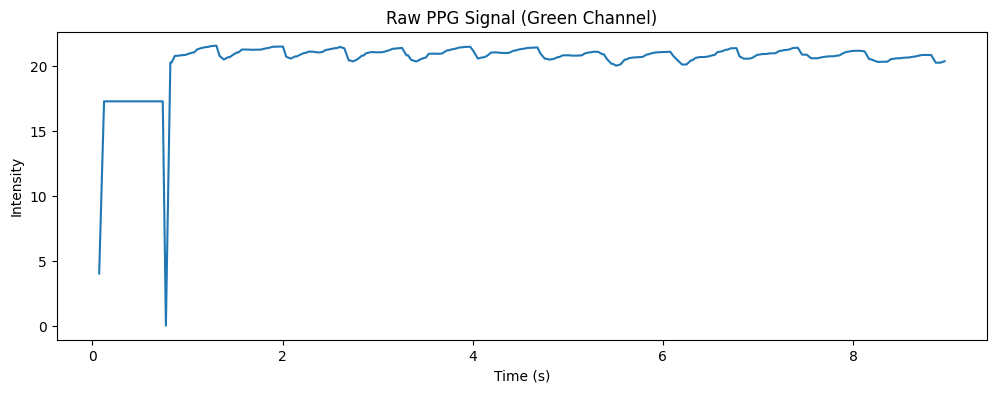

In [13]:
import cv2
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIGURATION
# -----------------------------
CAMERA_INDEX = 2          # your phone camera
RECORD_SECONDS = 120      # recording duration
OUTPUT_FILE = "raw_ppg_signal.csv"

# -----------------------------
# VIDEO CAPTURE
# -----------------------------
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

# Optional: lower resolution for stability
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("✅ Camera opened successfully")
print("📹 Recording PPG... Place finger on camera and keep still")

ppg_signal = []
timestamps = []

start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Extract GREEN channel
    green_channel = rgb[:, :, 1]

    # Mean pixel intensity = PPG value
    ppg_value = np.mean(green_channel)

    ppg_signal.append(ppg_value)
    timestamps.append(time.time() - start_time)

    # Display live feed
    cv2.imshow("Live PPG Capture (Press Q to stop)", frame)

    # Stop after fixed duration
    if time.time() - start_time > RECORD_SECONDS:
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# -----------------------------
# SAVE TO CSV
# -----------------------------
df = pd.DataFrame({
    "time_sec": timestamps,
    "ppg_raw": ppg_signal
})

df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Raw PPG saved as {OUTPUT_FILE}")

# -----------------------------
# QUICK VISUALIZATION
# -----------------------------
plt.figure(figsize=(12,4))
plt.plot(df["time_sec"], df["ppg_raw"])
plt.title("Raw PPG Signal (Green Channel)")
plt.xlabel("Time (s)")
plt.ylabel("Intensity")
plt.show()


# V2
Refinement\
Dscarded initial 5 seconds of recordings\
Added seconds meter on the fideo frame\
printed sampling rate

✅ Camera opened successfully
📹 Recording PPG...
⏳ First 5 seconds will be ignored
📊 Effective Sampling Rate: 30.01 Hz
✅ Raw PPG saved as raw_ppg_signal.csv


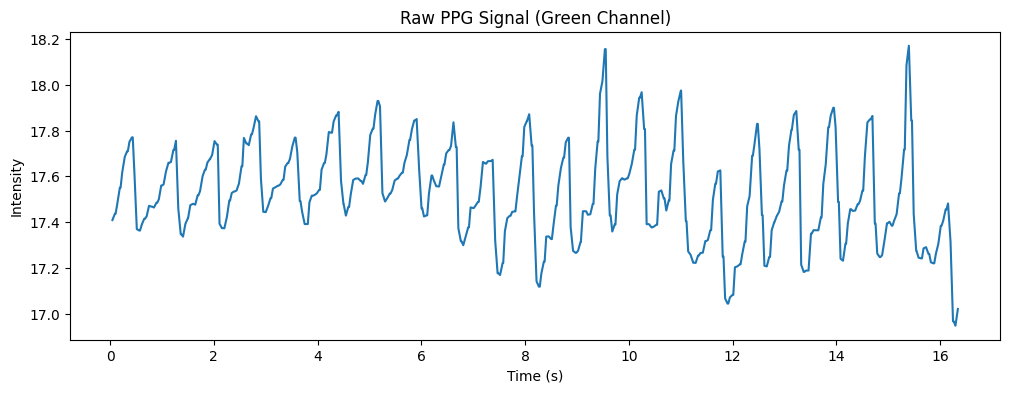

In [17]:
import cv2
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIGURATION
# -----------------------------
CAMERA_INDEX = 2
RECORD_SECONDS = 120        # total recording time (including warm-up)
WARMUP_SECONDS = 5          # ignore first 5 seconds
OUTPUT_FILE = "raw_ppg_signal.csv"

# -----------------------------
# VIDEO CAPTURE
# -----------------------------
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

# Reduce resolution for stability
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("✅ Camera opened successfully")
print("📹 Recording PPG...")
print(f"⏳ First {WARMUP_SECONDS} seconds will be ignored")

ppg_signal = []
timestamps = []

start_time = time.time()
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_time = time.time() - start_time

    # Convert to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    green_channel = rgb[:, :, 1]

    # Compute PPG value
    ppg_value = np.mean(green_channel)

    # ✅ Ignore first WARMUP_SECONDS
    if current_time > WARMUP_SECONDS:
        ppg_signal.append(ppg_value)
        timestamps.append(current_time - WARMUP_SECONDS)
        frame_count += 1

    # -----------------------------
    # DISPLAY RECORDING TIME
    # -----------------------------
    display_text = f"Recording: {current_time:.1f} s"
    cv2.putText(
        frame,
        display_text,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow("Live PPG Capture (Press Q to stop)", frame)

    # Stop conditions
    if current_time > RECORD_SECONDS:
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# -----------------------------
# SAMPLING RATE CALCULATION
# -----------------------------
if len(timestamps) > 1:
    duration = timestamps[-1] - timestamps[0]
    sampling_rate = frame_count / duration
else:
    sampling_rate = 0

print(f"📊 Effective Sampling Rate: {sampling_rate:.2f} Hz")

# -----------------------------
# SAVE TO CSV
# -----------------------------
df = pd.DataFrame({
    "time_sec": timestamps,
    "ppg_raw": ppg_signal
})

df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Raw PPG saved as {OUTPUT_FILE}")

# -----------------------------
# QUICK VISUALIZATION
# -----------------------------
plt.figure(figsize=(12, 4))
plt.plot(df["time_sec"], df["ppg_raw"])
plt.title("Raw PPG Signal (Green Channel)")
plt.xlabel("Time (s)")
plt.ylabel("Intensity")
plt.show()


Training data used:\
80-second segments\
Clean, controlled signals\
125 Hz sampling\

Phone-based setup:\
Lower sampling rate (~30 Hz)\
More noise\

We require more seconds of recordings i.e. \
90–120 seconds on phone ≈ 80 seconds in dataset

# V3

Asks patient name and patient ID\
Alterts at:\
90s: Minimum data collected\
120s: Recommended data collected\

Automatically stops recording at 150s


✅ Camera opened successfully
📹 Place finger on camera & stay still
⏳ First 5 seconds will be ignored

🟢 90 seconds reached: Minimum data collected
🟢 120 seconds reached: Recommended data collected

🔴 150 seconds reached: Recording stopped automatically

📊 Effective Sampling Rate: 29.97 Hz
✅ Raw PPG saved as: PPG_1.csv


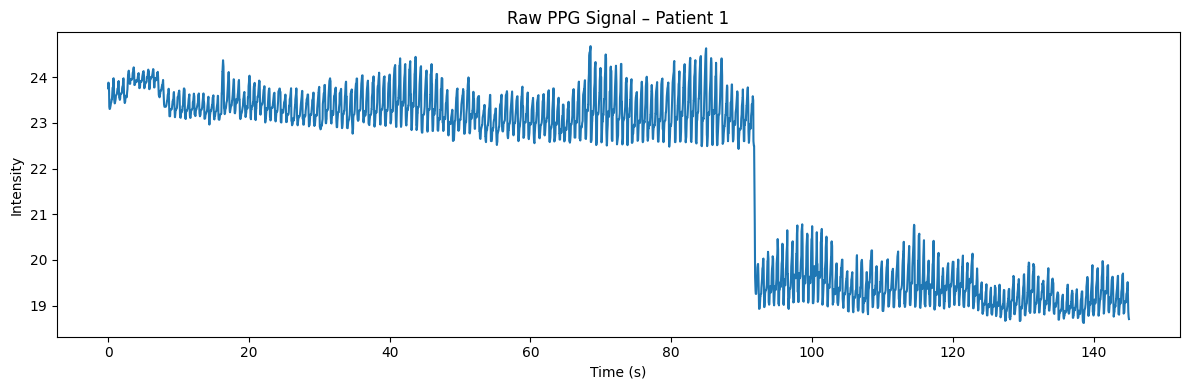

In [19]:
import cv2
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# PATIENT DETAILS
# =============================
patient_name = input("Enter Patient Name: ")
patient_id = input("Enter Patient ID: ")

# =============================
# CONFIGURATION
# =============================
CAMERA_INDEX = 2
WARMUP_SECONDS = 5
SIGNAL_90 = 90
SIGNAL_120 = 120
STOP_AT = 150

OUTPUT_FILE = f"PPG_{patient_id}.csv"

# =============================
# VIDEO CAPTURE
# =============================
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("\n✅ Camera opened successfully")
print("📹 Place finger on camera & stay still")
print(f"⏳ First {WARMUP_SECONDS} seconds will be ignored\n")

ppg_signal = []
timestamps = []

start_time = time.time()
frame_count = 0
flag_90 = False
flag_120 = False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    elapsed = time.time() - start_time

    # Convert to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    green = rgb[:, :, 1]
    ppg_value = np.mean(green)

    # =============================
    # VALID RECORDING (after warmup)
    # =============================
    if elapsed > WARMUP_SECONDS:
        valid_time = elapsed - WARMUP_SECONDS
        ppg_signal.append(ppg_value)
        timestamps.append(valid_time)
        frame_count += 1

        # ---- SIGNAL POINTS ----
        if valid_time >= SIGNAL_90 and not flag_90:
            print("🟢 90 seconds reached: Minimum data collected")
            flag_90 = True

        if valid_time >= SIGNAL_120 and not flag_120:
            print("🟢 120 seconds reached: Recommended data collected")
            flag_120 = True
    else:
        valid_time = 0

    # =============================
    # DISPLAY TEXT ON FRAME
    # =============================
    cv2.putText(
        frame,
        f"Time: {elapsed:.1f}s",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Patient: {patient_name}",
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    cv2.imshow("Live PPG Capture (Press Q to stop)", frame)

    # =============================
    # STOP CONDITIONS
    # =============================
    if elapsed >= STOP_AT:
        print("\n🔴 150 seconds reached: Recording stopped automatically")
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("\n⏹ Recording stopped manually")
        break

cap.release()
cv2.destroyAllWindows()

# =============================
# SAMPLING RATE
# =============================
if len(timestamps) > 1:
    duration = timestamps[-1] - timestamps[0]
    sampling_rate = frame_count / duration
else:
    sampling_rate = 0

print(f"\n📊 Effective Sampling Rate: {sampling_rate:.2f} Hz")

# =============================
# SAVE TO CSV
# =============================
df = pd.DataFrame({
    "patient_name": patient_name,
    "patient_id": patient_id,
    "time_sec": timestamps,
    "ppg_raw": ppg_signal
})

df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Raw PPG saved as: {OUTPUT_FILE}")

# =============================
# VISUALIZE SIGNAL
# =============================
plt.figure(figsize=(12, 4))
plt.plot(df["time_sec"], df["ppg_raw"])
plt.title(f"Raw PPG Signal – Patient {patient_id}")
plt.xlabel("Time (s)")
plt.ylabel("Intensity")
plt.tight_layout()
plt.show()


# V4
Added plotly support for interactive plots and observing ppg signals more effectively.

In [21]:
import cv2
import numpy as np
import time
import pandas as pd
import plotly.graph_objects as go

# =============================
# PATIENT DETAILS
# =============================
patient_name = input("Enter Patient Name: ")
patient_id = input("Enter Patient ID: ")

# =============================
# CONFIGURATION
# =============================
CAMERA_INDEX = 2
WARMUP_SECONDS = 5
SIGNAL_90 = 90
SIGNAL_120 = 120
STOP_AT = 150

OUTPUT_FILE = f"PPG_{patient_id}.csv"

# =============================
# VIDEO CAPTURE
# =============================
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("\n✅ Camera opened successfully")
print("📹 Place finger on camera & stay still")
print(f"⏳ First {WARMUP_SECONDS} seconds will be ignored\n")

ppg_signal = []
timestamps = []

start_time = time.time()
frame_count = 0
flag_90 = False
flag_120 = False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    elapsed = time.time() - start_time

    # Convert to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    green = rgb[:, :, 1]
    ppg_value = np.mean(green)

    # =============================
    # VALID RECORDING (after warmup)
    # =============================
    if elapsed > WARMUP_SECONDS:
        valid_time = elapsed - WARMUP_SECONDS
        ppg_signal.append(ppg_value)
        timestamps.append(valid_time)
        frame_count += 1

        # ---- SIGNAL POINTS ----
        if valid_time >= SIGNAL_90 and not flag_90:
            print("🟢 90 seconds reached: Minimum data collected")
            flag_90 = True

        if valid_time >= SIGNAL_120 and not flag_120:
            print("🟢 120 seconds reached: Recommended data collected")
            flag_120 = True
    else:
        valid_time = 0

    # =============================
    # DISPLAY TEXT ON FRAME
    # =============================
    cv2.putText(
        frame,
        f"Time: {elapsed:.1f}s",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Patient: {patient_name}",
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    cv2.imshow("Live PPG Capture (Press Q to stop)", frame)

    # =============================
    # STOP CONDITIONS
    # =============================
    if elapsed >= STOP_AT:
        print("\n🔴 150 seconds reached: Recording stopped automatically")
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("\n⏹ Recording stopped manually")
        break

cap.release()
cv2.destroyAllWindows()

# =============================
# SAMPLING RATE
# =============================
if len(timestamps) > 1:
    duration = timestamps[-1] - timestamps[0]
    sampling_rate = frame_count / duration
else:
    sampling_rate = 0

print(f"\n📊 Effective Sampling Rate: {sampling_rate:.2f} Hz")

# =============================
# SAVE TO CSV
# =============================
df = pd.DataFrame({
    "patient_name": patient_name,
    "patient_id": patient_id,
    "time_sec": timestamps,
    "ppg_raw": ppg_signal
})

df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Raw PPG saved as: {OUTPUT_FILE}")


# =============================
# INTERACTIVE PLOTLY VISUALIZATION
# =============================
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["time_sec"],
        y=df["ppg_raw"],
        mode="lines",
        name="Raw PPG (Green Channel)",
        line=dict(
            color="red",     # 🔴 RED signal
            width=1.8
        )
    )
)

fig.update_layout(
    title=dict(
        text=f"Raw PPG Signal – Patient {patient_id}",
        x=0.5
    ),
    xaxis=dict(
        title="Time (seconds)",
        rangeslider=dict(visible=True),   # ⏱ Time slider
        type="linear"
    ),
    yaxis=dict(
        title="Intensity"
    ),
    template="plotly_dark",              # 🌙 Dark theme
    height=500
)

# Optional: mark key time points
fig.add_vline(x=90,  line_dash="dash", line_color="green",
              annotation_text="90 s", annotation_position="top")
fig.add_vline(x=120, line_dash="dash", line_color="cyan",
              annotation_text="120 s", annotation_position="top")

fig.show()




✅ Camera opened successfully
📹 Place finger on camera & stay still
⏳ First 5 seconds will be ignored

🟢 90 seconds reached: Minimum data collected

⏹ Recording stopped manually

📊 Effective Sampling Rate: 29.98 Hz
✅ Raw PPG saved as: PPG_3.csv


In [1]:
import cv2
import numpy as np
import time
import pandas as pd
import plotly.graph_objects as go
import os

# =============================
# PATIENT DETAILS
# =============================
patient_name = input("Enter Patient Name: ")
patient_id = input("Enter Patient ID: ")

# =============================
# CONFIGURATION
# =============================
CAMERA_INDEX = 2
WARMUP_SECONDS = 5
SIGNAL_90 = 90
SIGNAL_120 = 120
STOP_AT = 150

# ✅ SAVE LOCATION
BASE_PATH = r"B:\College\C_Codes\College\SEM_8\AF Detection"
CAPTURE_DIR = BASE_PATH + r"\Capturing"
os.makedirs(CAPTURE_DIR, exist_ok=True)

OUTPUT_FILE = CAPTURE_DIR + fr"\PPG_{patient_id}.csv"

# =============================
# VIDEO CAPTURE
# =============================
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("\n✅ Camera opened successfully")
print("📹 Place finger on camera & stay still")
print(f"⏳ First {WARMUP_SECONDS} seconds will be ignored\n")

ppg_signal = []
timestamps = []

start_time = time.time()
frame_count = 0
flag_90 = False
flag_120 = False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    elapsed = time.time() - start_time

    # Convert to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    green = rgb[:, :, 1]
    ppg_value = np.mean(green)

    # =============================
    # VALID RECORDING (after warmup)
    # =============================
    if elapsed > WARMUP_SECONDS:
        valid_time = elapsed - WARMUP_SECONDS
        ppg_signal.append(ppg_value)
        timestamps.append(valid_time)
        frame_count += 1

        if valid_time >= SIGNAL_90 and not flag_90:
            print("🟢 90 seconds reached: Minimum data collected")
            flag_90 = True

        if valid_time >= SIGNAL_120 and not flag_120:
            print("🟢 120 seconds reached: Recommended data collected")
            flag_120 = True

    # =============================
    # DISPLAY TEXT ON FRAME
    # =============================
    cv2.putText(frame, f"Time: {elapsed:.1f}s",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.putText(frame, f"Patient: {patient_name}",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.imshow("Live PPG Capture (Press Q to stop)", frame)

    if elapsed >= STOP_AT:
        print("\n🔴 150 seconds reached: Recording stopped automatically")
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("\n⏹ Recording stopped manually")
        break

cap.release()
cv2.destroyAllWindows()

# =============================
# SAMPLING RATE
# =============================
if len(timestamps) > 1:
    duration = timestamps[-1] - timestamps[0]
    sampling_rate = frame_count / duration
else:
    sampling_rate = 0

print(f"\n📊 Effective Sampling Rate: {sampling_rate:.2f} Hz")

# =============================
# SAVE TO CSV (✅ NEW LOCATION)
# =============================
df = pd.DataFrame({
    "patient_name": patient_name,
    "patient_id": patient_id,
    "time_sec": timestamps,
    "ppg_raw": ppg_signal
})

df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Raw PPG saved at:\n{OUTPUT_FILE}")

# =============================
# INTERACTIVE PLOTLY VISUALIZATION
# =============================
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["time_sec"],
        y=df["ppg_raw"],
        mode="lines",
        name="Raw PPG (Green Channel)",
        line=dict(color="red", width=1.8)
    )
)

fig.update_layout(
    title=dict(
        text=f"Raw PPG Signal – Patient {patient_id}",
        x=0.5
    ),
    xaxis=dict(
        title="Time (seconds)",
        rangeslider=dict(visible=True),
        type="linear"
    ),
    yaxis=dict(title="Intensity"),
    template="plotly_dark",
    height=500
)

fig.add_vline(x=90,  line_dash="dash", line_color="green", annotation_text="90 s")
fig.add_vline(x=120, line_dash="dash", line_color="cyan",  annotation_text="120 s")

fig.show()



✅ Camera opened successfully
📹 Place finger on camera & stay still
⏳ First 5 seconds will be ignored

🟢 90 seconds reached: Minimum data collected

⏹ Recording stopped manually

📊 Effective Sampling Rate: 29.97 Hz
✅ Raw PPG saved at:
B:\College\C_Codes\College\SEM_8\AF Detection\Capturing\PPG_2.csv
